In [2]:
#BT2.11
!pip install scikit-fuzzy

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

distance = ctrl.Antecedent(np.arange(0, 51, 1), 'distance') # km
traffic = ctrl.Antecedent(np.arange(0, 101, 1), 'traffic')   # % tắc nghẽn
price = ctrl.Consequent(np.arange(0, 201, 1), 'price')      # Nghìn đồng

distance['short'] = fuzz.trapmf(distance.universe, [0, 0, 3, 5])
distance['medium'] = fuzz.trimf(distance.universe, [3, 10, 15])
distance['long'] = fuzz.trapmf(distance.universe, [12, 20, 50, 50])

traffic['low'] = fuzz.trimf(traffic.universe, [0, 0, 40])
traffic['medium'] = fuzz.trimf(traffic.universe, [30, 50, 70])
traffic['high'] = fuzz.trimf(traffic.universe, [60, 100, 100])

price['low'] = fuzz.trimf(price.universe, [0, 20, 50])
price['medium'] = fuzz.trimf(price.universe, [40, 80, 120])
price['high'] = fuzz.trimf(price.universe, [100, 150, 200])

rule1 = ctrl.Rule(distance['short'] & traffic['low'], price['low'])
rule2 = ctrl.Rule(distance['medium'] & traffic['medium'], price['medium'])
rule3 = ctrl.Rule(distance['long'] | traffic['high'], price['high'])

grab_price_ctrl = ctrl.ControlSystem([rule1, rule2, rule3])
grab_price_sim = ctrl.ControlSystemSimulation(grab_price_ctrl)

grab_price_sim.input['distance'] = 4
grab_price_sim.input['traffic'] = 20
grab_price_sim.compute()

print(f"Giá cước dự toán (2.11): {grab_price_sim.output['price']:.2f} nghìn VNĐ")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 20.3 MB/s eta 0:00:00
Giá cước dự toán (2.11): 23.89 nghìn VNĐ


In [3]:
#BT2.12

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

customer_rating = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'rating')
delivery_dist = ctrl.Antecedent(np.arange(0, 31, 1), 'dist')
discount = ctrl.Consequent(np.arange(0, 51, 1), 'discount') # % giảm giá

customer_rating['low'] = fuzz.trimf(customer_rating.universe, [0, 0, 3])
customer_rating['high'] = fuzz.trimf(customer_rating.universe, [3, 5, 5])

delivery_dist['near'] = fuzz.trimf(delivery_dist.universe, [0, 0, 10])
delivery_dist['far'] = fuzz.trimf(delivery_dist.universe, [8, 30, 30])

discount['low'] = fuzz.trimf(discount.universe, [0, 5, 15])
discount['high'] = fuzz.trimf(discount.universe, [10, 25, 50])

rule1 = ctrl.Rule(customer_rating['high'] & delivery_dist['far'], discount['high'])
rule2 = ctrl.Rule(customer_rating['low'], discount['low'])

shopee_disc_ctrl = ctrl.ControlSystem([rule1, rule2])
shopee_disc_sim = ctrl.ControlSystemSimulation(shopee_disc_ctrl)

shopee_disc_sim.input['rating'] = 4.5
shopee_disc_sim.input['dist'] = 20
shopee_disc_sim.compute()

print(f"Tỉ lệ chiết khấu đề xuất (2.12): {shopee_disc_sim.output['discount']:.2f}%")

Tỉ lệ chiết khấu đề xuất (2.12): 28.81%


In [4]:
#BT2.13

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

demand = ctrl.Antecedent(np.arange(0, 101, 1), 'demand')  # Nhu cầu (%)
margin = ctrl.Antecedent(np.arange(0, 101, 1), 'margin')  # Biên lợi nhuận (%)
promo_disc = ctrl.Consequent(np.arange(0, 71, 1), 'promo_disc')

demand['low'] = fuzz.trimf(demand.universe, [0, 0, 50])
demand['high'] = fuzz.trimf(demand.universe, [40, 100, 100])

margin['low'] = fuzz.trimf(margin.universe, [0, 0, 40])
margin['high'] = fuzz.trimf(margin.universe, [30, 100, 100])

promo_disc['small'] = fuzz.trimf(promo_disc.universe, [0, 10, 25])
promo_disc['large'] = fuzz.trimf(promo_disc.universe, [20, 45, 70])

rule1 = ctrl.Rule(demand['high'] & margin['high'], promo_disc['large'])
rule2 = ctrl.Rule(demand['low'] | margin['low'], promo_disc['small'])

strategy_ctrl = ctrl.ControlSystem([rule1, rule2])
strategy_sim = ctrl.ControlSystemSimulation(strategy_ctrl)

strategy_sim.input['demand'] = 85
strategy_sim.input['margin'] = 60
strategy_sim.compute()

print(f"Mức giảm giá chiến lược (2.13): {strategy_sim.output['promo_disc']:.2f}%")

Mức giảm giá chiến lược (2.13): 45.00%


In [5]:
#BT.14

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

order_density = ctrl.Antecedent(np.arange(0, 11, 1), 'density') # Đơn/vùng
driver_load = ctrl.Antecedent(np.arange(0, 101, 1), 'load')     # % tải trọng
combine_score = ctrl.Consequent(np.arange(0, 11, 1), 'combine') # Điểm ưu tiên gom đơn

order_density['low'] = fuzz.trimf(order_density.universe, [0, 0, 5])
order_density['high'] = fuzz.trimf(order_density.universe, [4, 10, 10])

driver_load['light'] = fuzz.trimf(driver_load.universe, [0, 0, 60])
driver_load['heavy'] = fuzz.trimf(driver_load.universe, [50, 100, 100])

combine_score['no'] = fuzz.trimf(combine_score.universe, [0, 0, 5])
combine_score['yes'] = fuzz.trimf(combine_score.universe, [5, 10, 10])

rule1 = ctrl.Rule(order_density['high'] & driver_load['light'], combine_score['yes'])
rule2 = ctrl.Rule(order_density['low'] | driver_load['heavy'], combine_score['no'])

logistics_ctrl = ctrl.ControlSystem([rule1, rule2])
logistics_sim = ctrl.ControlSystemSimulation(logistics_ctrl)

logistics_sim.input['density'] = 8
logistics_sim.input['load'] = 20
logistics_sim.compute()

print(f"Mức độ ưu tiên gom đơn (2.14): {logistics_sim.output['combine']:.2f}/10")

Mức độ ưu tiên gom đơn (2.14): 8.19/10


Thời gian giặt dự đoán: 8.28
Mức nước dự đoán: 8.28


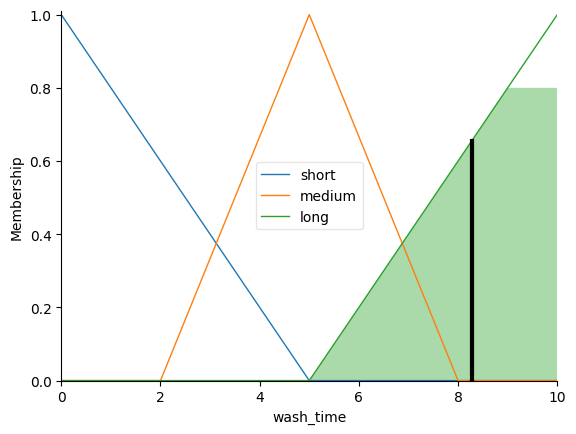

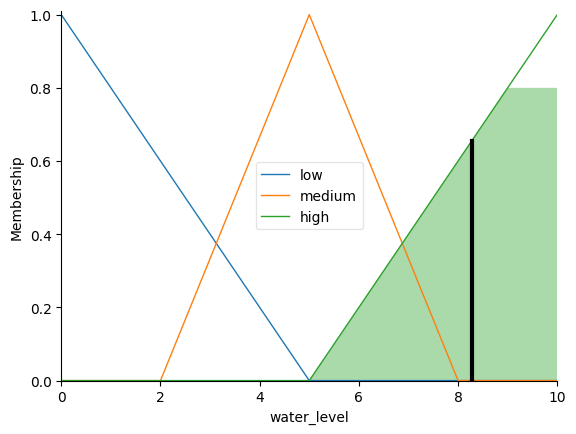

In [8]:

!pip install scikit-fuzzy

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

load = ctrl.Antecedent(np.arange(0, 11, 1), 'load')         # khối lượng tải
dirt = ctrl.Antecedent(np.arange(0, 11, 1), 'dirt')         # mức độ bẩn
fabric = ctrl.Antecedent(np.arange(0, 11, 1), 'fabric')     # loại vải
wash_time = ctrl.Consequent(np.arange(0, 11, 1), 'wash_time')
water_level = ctrl.Consequent(np.arange(0, 11, 1), 'water_level')

load['small'] = fuzz.trimf(load.universe, [0, 0, 5])
load['medium'] = fuzz.trimf(load.universe, [2, 5, 8])
load['large'] = fuzz.trimf(load.universe, [5, 10, 10])

dirt['low'] = fuzz.trimf(dirt.universe, [0, 0, 5])
dirt['medium'] = fuzz.trimf(dirt.universe, [2, 5, 8])
dirt['high'] = fuzz.trimf(dirt.universe, [5, 10, 10])

fabric['delicate'] = fuzz.trimf(fabric.universe, [0, 0, 5])
fabric['normal'] = fuzz.trimf(fabric.universe, [2, 5, 8])
fabric['heavy'] = fuzz.trimf(fabric.universe, [5, 10, 10])

wash_time['short'] = fuzz.trimf(wash_time.universe, [0, 0, 5])
wash_time['medium'] = fuzz.trimf(wash_time.universe, [2, 5, 8])
wash_time['long'] = fuzz.trimf(wash_time.universe, [5, 10, 10])

water_level['low'] = fuzz.trimf(water_level.universe, [0, 0, 5])
water_level['medium'] = fuzz.trimf(water_level.universe, [2, 5, 8])
water_level['high'] = fuzz.trimf(water_level.universe, [5, 10, 10])

rule1 = ctrl.Rule(load['small'] & dirt['low'], (wash_time['short'], water_level['low']))
rule2 = ctrl.Rule(load['small'] & dirt['medium'], (wash_time['medium'], water_level['medium']))
rule3 = ctrl.Rule(load['small'] & dirt['high'], (wash_time['long'], water_level['medium']))
rule4 = ctrl.Rule(load['medium'] & dirt['low'], (wash_time['medium'], water_level['medium']))
rule5 = ctrl.Rule(load['medium'] & dirt['medium'], (wash_time['long'], water_level['medium']))
rule6 = ctrl.Rule(load['medium'] & dirt['high'], (wash_time['long'], water_level['high']))
rule7 = ctrl.Rule(load['large'] & dirt['low'], (wash_time['medium'], water_level['high']))
rule8 = ctrl.Rule(load['large'] & dirt['medium'], (wash_time['long'], water_level['high']))
rule9 = ctrl.Rule(load['large'] & dirt['high'], (wash_time['long'], water_level['high']))
rule10 = ctrl.Rule(fabric['delicate'], (wash_time['short'], water_level['low']))
rule11 = ctrl.Rule(fabric['heavy'], (wash_time['long'], water_level['high']))
rule12 = ctrl.Rule(load['large'] & dirt['high'] & fabric['heavy'], (wash_time['long'], water_level['high']))
rule13 = ctrl.Rule(load['small'] & dirt['low'] & fabric['delicate'], (wash_time['short'], water_level['low']))
rule14 = ctrl.Rule(load['medium'] & dirt['medium'] & fabric['normal'], (wash_time['medium'], water_level['medium']))

washing_ctrl = ctrl.ControlSystem([
    rule1, rule2, rule3, rule4, rule5, rule6,
    rule7, rule8, rule9, rule10, rule11,
    rule12, rule13, rule14
])
washing = ctrl.ControlSystemSimulation(washing_ctrl)

washing.input['load'] = 7
washing.input['dirt'] = 8
washing.input['fabric'] = 9

washing.compute()

print(f"Thời gian giặt dự đoán: {washing.output['wash_time']:.2f}")
print(f"Mức nước dự đoán: {washing.output['water_level']:.2f}")

wash_time.view(sim=washing)
water_level.view(sim=washing)
plt.show()